In [78]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [79]:
img = cv2.imread(r"C:\Users\HP\Desktop\dataset\sharapova\sharapova-1.jpg")
img.shape

(555, 700, 3)

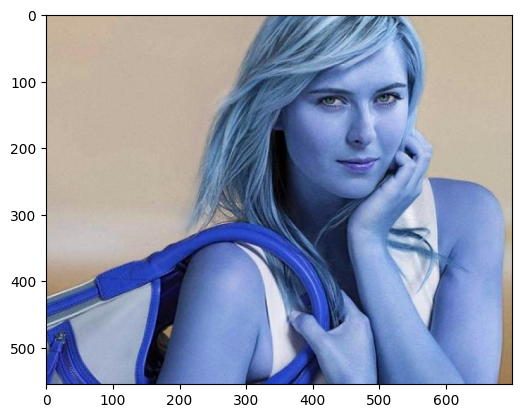

In [80]:
plt.imshow(img)

In [50]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

In [51]:
gray

array([[175, 175, 175, ..., 176, 175, 174],
       [175, 175, 175, ..., 177, 175, 174],
       [175, 175, 175, ..., 177, 176, 174],
       ...,
       [ 84,  87,  88, ..., 113, 113, 113],
       [ 88,  89,  90, ..., 113, 113, 113],
       [ 93,  91,  91, ..., 112, 112, 112]], shape=(555, 700), dtype=uint8)

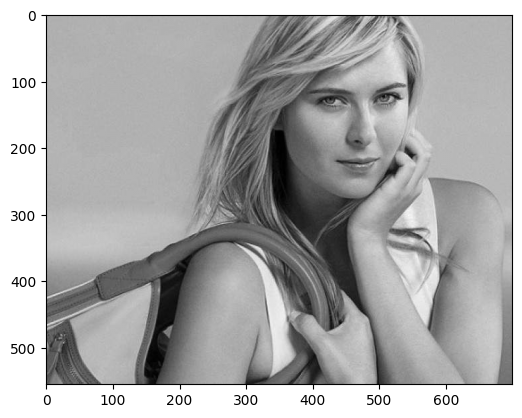

In [52]:
plt.imshow(gray, cmap='gray')

In [53]:
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Check if loaded correctly
if face_cascade.empty() or eye_cascade.empty():
    print("Error loading cascade files!")
else:
    print("Cascade loaded successfully!")

Cascade loaded successfully!


In [56]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

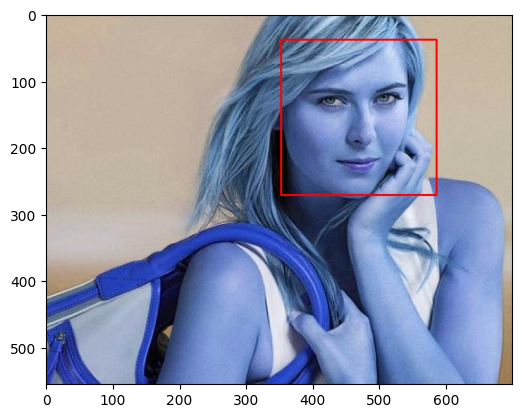

In [57]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

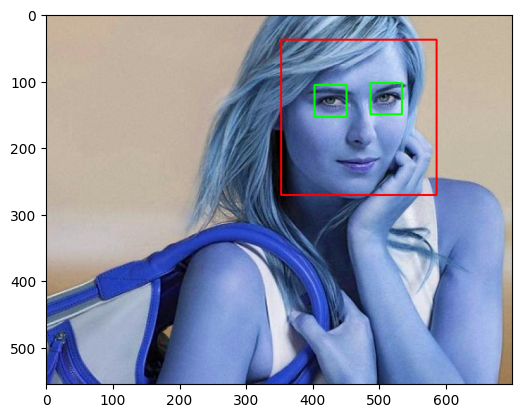

In [59]:
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

for (x, y, w, h) in faces:
    # Extract region of interest (ROI) for face
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]

    # Detect eyes using the EYE cascade
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

plt.figure()
plt.imshow(face_img, cmap='gray')
cv2.destroyAllWindows()

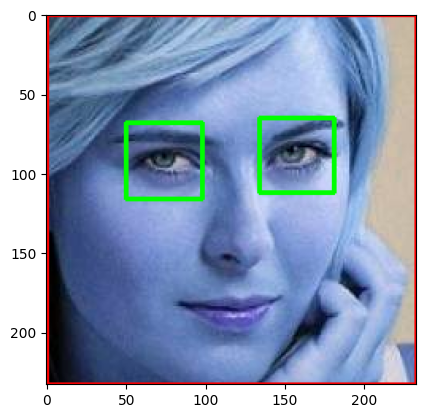

In [60]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [61]:
cropped_img = np.array(roi_color)
cropped_img.shape

(233, 233, 3)

In [62]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

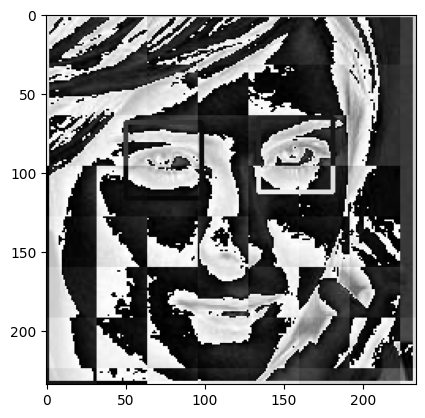

In [63]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')

In [64]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

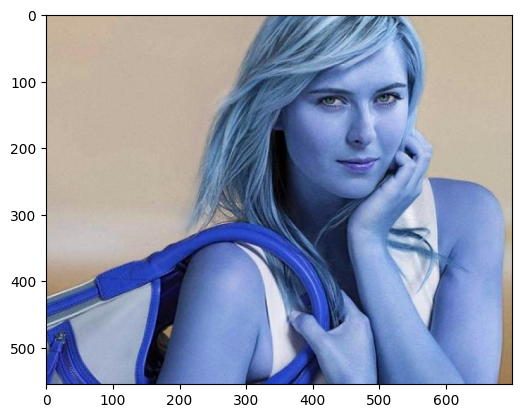

In [81]:
original_image = cv2.imread(r"C:\Users\HP\Desktop\dataset\sharapova\sharapova-1.jpg")
plt.imshow(original_image)

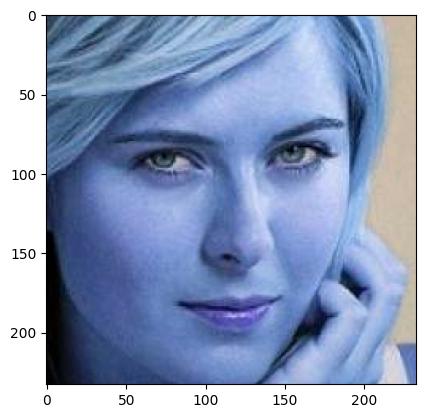

In [82]:
cropped_image = get_cropped_image_if_2_eyes(r"C:\Users\HP\Desktop\dataset\sharapova\sharapova-1.jpg")
plt.imshow(cropped_image)

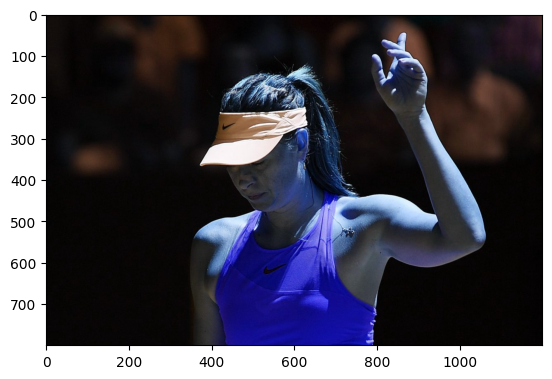

In [74]:
org_image_obstructed = cv2.imread(r"C:\Users\HP\Desktop\dataset\sharapova\sharapova-2.jpg")
plt.imshow(org_image_obstructed)

In [73]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes(r"C:\Users\HP\Desktop\dataset\sharapova\sharapova-2.jpg")
cropped_image_no_2_eyes

In [91]:
path_to_data = r"C:\Users\HP\Desktop\dataset\celebs"
path_to_cr_data = r"C:\Users\HP\Desktop\dataset\cropped"

In [92]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [93]:
img_dirs

['C:\\Users\\HP\\Desktop\\dataset\\celebs\\federer',
 'C:\\Users\\HP\\Desktop\\dataset\\celebs\\kohli',
 'C:\\Users\\HP\\Desktop\\dataset\\celebs\\messi',
 'C:\\Users\\HP\\Desktop\\dataset\\celebs\\sharapova',
 'C:\\Users\\HP\\Desktop\\dataset\\celebs\\williams']

In [94]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [96]:
import os
import re
import cv2

cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    # Extract folder name safely
    celebrity_name = os.path.basename(img_dir)
    # Remove invalid Windows characters from folder name
    celebrity_name = re.sub(r'[<>:"/\\|?*]', '', celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)  # your custom function
        if roi_color is not None:
            # Safely create cropped folder path
            cropped_folder = os.path.join(path_to_cr_data, celebrity_name)
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder, exist_ok=True)
                print("Generating cropped images in folder:", cropped_folder)
                # Add folder once when created
                cropped_image_dirs.append(cropped_folder)

            # Safely create cropped file path
            cropped_file_name = f"{celebrity_name}{count}.png"
            cropped_file_path = os.path.join(cropped_folder, cropped_file_name)

            # Save the cropped image
            cv2.imwrite(cropped_file_path, roi_color)

            # Store path in dictionary
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

Generating cropped images in folder: C:\Users\HP\Desktop\dataset\cropped\federer
Generating cropped images in folder: C:\Users\HP\Desktop\dataset\cropped\kohli
Generating cropped images in folder: C:\Users\HP\Desktop\dataset\cropped\messi
Generating cropped images in folder: C:\Users\HP\Desktop\dataset\cropped\sharapova
Generating cropped images in folder: C:\Users\HP\Desktop\dataset\cropped\williams


In [102]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer': ['C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer1.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer10.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer11.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer12.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer13.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer14.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer15.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer16.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer17.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer18.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer19.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer2.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer\\federer20.png',
  'C:\\Users\\HP\\Desktop\\dataset\\cro

In [100]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer': 0,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\kohli': 1,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\messi': 2,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\sharapova': 3,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\williams': 4}

In [103]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])     
len(X[0])

4096

In [104]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(164, 4096)

In [105]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)


0.8048780487804879

In [109]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.77      0.91      0.83        11
           2       0.83      0.83      0.83         6
           3       0.62      0.71      0.67         7
           4       1.00      0.82      0.90        11

    accuracy                           0.80        41
   macro avg       0.81      0.79      0.79        41
weighted avg       0.82      0.80      0.81        41



In [110]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [111]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [112]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid t

,model,best_score,best_params
0,svm,0.853333,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.650333,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.845000,{'logisticregression__C': 1}


In [113]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [114]:
best_estimators['svm'].score(X_test,y_test)

0.9024390243902439

In [115]:
best_estimators['random_forest'].score(X_test,y_test)

0.7073170731707317

In [116]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.926829268292683

In [117]:
best_clf = best_estimators['svm']

In [118]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[ 5,  0,  0,  1,  0],
       [ 0, 11,  0,  0,  0],
       [ 0,  0,  6,  0,  0],
       [ 1,  0,  1,  5,  0],
       [ 0,  0,  0,  1, 10]])

Text(95.72222222222221, 0.5, 'Truth')

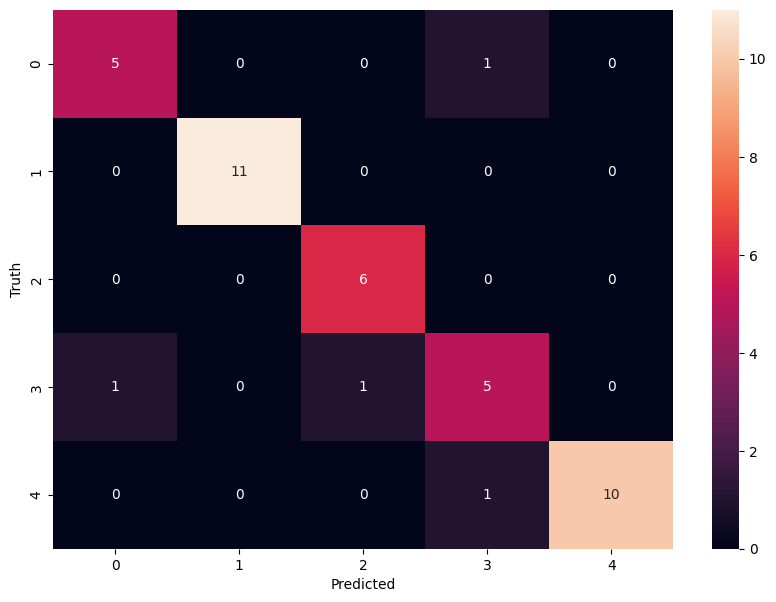

In [119]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [120]:
class_dict

{'C:\\Users\\HP\\Desktop\\dataset\\cropped\\federer': 0,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\kohli': 1,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\messi': 2,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\sharapova': 3,
 'C:\\Users\\HP\\Desktop\\dataset\\cropped\\williams': 4}

In [121]:
!pip install joblib
import joblib 
# Save the model as a pickle in a file 
joblib.dump(best_clf, 'saved_model.pkl') 

['saved_model.pkl']

In [122]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))